# Fixed schedule QAOA

In this tutorial we explore how to use the Quantum Approximate Optimization Algorithm (QAOA) to tackle a toy portfolio deversificatoin problem.
Specifically we will have a look at the Linear Ramp QAOA (LR-QAOA) introduced by Montanez-Barrera in 2024.

We consider a universe of $N$ assets, indexed by $i=0, \dots, N-1$, and a given correlation matrix $R \in \mathbb{R}^{N\times{}N}$. The entry $R_{i,j}$ measures how strongly asset $i$ and asset $j$ move together. From a diversification point of view, we want to avoid placing heighly correlated assets into the same risk bucket.

In [1]:
import numpy as np

R = np.array([
    [ 1.00,  0.75,  0.86, -0.23,  0.51,  0.67,  0.92],
    [ 0.75,  1.00, -0.59,  0.77,  0.83,  0.20, -0.38],
    [ 0.86, -0.59,  1.00,  0.13, -0.31,  0.80, -0.17],
    [-0.23,  0.77,  0.13,  1.00,  0.77,  0.52,  0.97],
    [ 0.51,  0.83, -0.31,  0.77,  1.00,  0.82, -0.52],
    [ 0.67,  0.20,  0.80,  0.52,  0.82,  1.00,  0.83],
    [ 0.92, -0.38, -0.17,  0.97, -0.52,  0.83,  1.00],
])

N = R.shape[0]

We model this as a weighted graph coloring-like problem;
* Each asset correspondes to a node.
* Each asset is assigned ot one of $K$ risk buckets (colors).
* Since the graph would be fully connected, we use the correlation as a weight.
* We encode the bucket assignment for each asset using a one-hot register of $K$ qubits.
* A bucket assignment is thus a string representing which bucket each asset is in.

## Implementing the risk buckets

In Qrisp, every QuantumVariable type (such as QuantumFloat) has a corresponding classical type and a quantum wrapper class that knows how to encode and decode that classical type into a quantum register. 
 The same pattern applies to QuantumEnum. In our setup we first define the classical enum ``RiskBucket``, inheriting from QuantumEnum.OneHot, and use Python’s ``enum.auto()`` to assign values to the three buckets ``A``, ``B``, and ``C``. 
 We want to use a onehot encoding for the risk buckets, so inheriting from ``QuantumEnum.OneHot`` tells pythons ``enum.auto()`` method to use this encoding enstead of a sequential one. 

 We then use ``@QuantumEnum.auto(RiskBucket)`` to generate the corresponding quantum enum class QuantumRiskBucket, which encapsulates the encoding of RiskBucket values into the one‑hot quantum register and their decoding back to classical enum values after measurement. This allows us to work at the quantum level with ``QuantumRiskBucket`` registers per asset, and after measurement to obtain clean classical ``RiskBucket`` assignments that we can directly pass to our classical cost function.

In [2]:
from qrisp import QuantumEnum
from enum import auto

class RiskBucket(QuantumEnum.OneHot):
    A = auto()
    B = auto()
    C = auto()

@QuantumEnum.auto(RiskBucket)
class QuantumRiskBucket(QuantumEnum):
    pass

## Implementing the cost function

The classical cost function is relativly simple to implement, given a string of buckets, or in our case an array of RiskBucket enum instances, where each entry encodes the bucket assignment $b_i$ of asset $i$.

For a given assignment, we want to realize the objective
$$
    C(b) = \sum_{i<j} R_{i,j} \delta_{b_i,b_j}
$$

where $R_{i,j}$ is the correlation between assets $i$ and $j$, as mentioned in the introduction, and $\delta_{b_i,b_j}$ is $1$ if both assets are in the same bucket and $0$ otherwise. In code, this becomes

In [3]:
def cost_fn(riskBuckets):
    cost = 0.0
    for i in range(N):
        for j in range(i+1, N):
            if riskBuckets[i] == riskBuckets[j]:
                cost += R[i, j]
    return cost

## The Linear Ramp QAOA

In [4]:
from qrisp import QuantumArray, x
from qrisp.qaoa import XY_mixer, RX_mixer

def ansatz(init_state, d_gamma, d_beta, depth):
    def linear_ramp(start, end, p):
        return [start+ (end-start)*i / (p-1) for i in range(p)]
    gammas = linear_ramp(0, d_gamma, depth)
    betas = linear_ramp(d_beta, 0, depth)

    # Warm start
    qarg = QuantumArray(qtype=QuantumRiskBucket(), shape=N)
    qarg[:] = init_state

    for gamma, beta in zip(gammas, betas):
        # Cost
        for i in range(N):
            for j in range(i + 1, N):
                qarg[i].apply_phase_if_eq(qarg[j], gamma * R[i, j])

        # Mixer
        for quantumRiskBucket in qarg:
            XY_mixer(quantumRiskBucket, beta)

    return qarg

In [5]:
def quantum_objective(theta, *args):
    d_gamma, d_beta = theta
    initial_state, depth = args

    qarg = ansatz(initial_state, d_gamma, d_beta, depth)
    
    energy = 0.0
    for meas, prob in qarg.get_measurement().items():
        cost = cost_fn(meas)
        energy += cost * prob
        
    return -energy


In [6]:
import random
from scipy.optimize import minimize

init_state = [random.choice(list(RiskBucket)) for _ in range(N)]
depth = 10

d_gamma, d_beta = minimize(
    quantum_objective, 
    args=(init_state, depth),
    x0=np.pi * np.random.rand(2, ), 
    method="COBYLA", 
    options={"maxiter": 500}
)['x']


In [7]:
qarg = ansatz(
    init_state, 
    d_gamma, 
    d_beta, 
    depth
)
results = qarg.get_measurement()

0.0014764955705132885


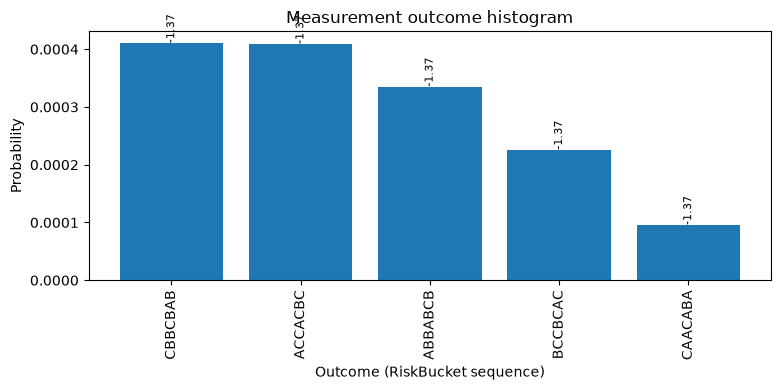

In [8]:
import matplotlib.pyplot as plt

probs = {k: p for k, p in results.items() if cost_fn(k) <= -1.37}
#probs = {k: p for k, p in results.items() if p > 0.002}
p_optimal = sum([p for k, p in results.items() if cost_fn(k) == -1.37])
print(p_optimal)


def outcome_label(outcome_array):
    buckets = list(outcome_array)
    return "".join(b.name for b in buckets)

labels = [outcome_label(k) for k, _ in probs.items()]
values = [v for _, v in probs.items()]
cost = [cost_fn(k) for k, _ in probs.items()]

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(labels))
bars = ax.bar(x, values, color='#1f77b4')

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=90)
ax.set_ylabel('Probability')
ax.set_xlabel('Outcome (RiskBucket sequence)')
ax.set_title('Measurement outcome histogram')

for xi, bar, c in zip(x, bars, cost):
    height = bar.get_height()
    ax.text(
        xi, height,
        f"{c:.2f}",
        ha='center', va='bottom',
        fontsize=8, rotation=90,
    )

plt.tight_layout()

In [9]:
import itertools

def brute_force_best_risk_buckets(objective_fn, buckets, length=7):
    best_sequence = None
    best_value = None

    for seq in itertools.product(buckets, repeat=length):
        value = objective_fn(seq)

        if best_value is None or value < best_value:  # change to > if you want max
            best_value = value
            best_sequence = seq

    return best_sequence, best_value

In [10]:
brute_force_best_risk_buckets(cost_fn, list(RiskBucket))

((<RiskBucket.A: 1>,
  <RiskBucket.B: 2>,
  <RiskBucket.B: 2>,
  <RiskBucket.A: 1>,
  <RiskBucket.B: 2>,
  <RiskBucket.C: 4>,
  <RiskBucket.B: 2>),
 np.float64(-1.37))